In [1]:
!pip install gdown

In [2]:
import gdown
!gdown 1aBM0-Pt7Bw_D7t3NzoACsm5aD3ws9CzI

Downloading...
From (original): https://drive.google.com/uc?id=1aBM0-Pt7Bw_D7t3NzoACsm5aD3ws9CzI
From (redirected): https://drive.google.com/uc?id=1aBM0-Pt7Bw_D7t3NzoACsm5aD3ws9CzI&confirm=t&uuid=cc8183fe-f2c3-4031-82dd-b3687937ec61
To: /teamspace/studios/this_studio/ai-of-god-3.zip
100%|████████████████████████████████████████| 413M/413M [00:05<00:00, 72.5MB/s]


In [3]:
!unzip ai-of-god-3.zip

Archive:  ai-of-god-3.zip
replace Public_data/submission.csv.xlsx? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

^C


In [1]:
import pandas as pd
import numpy as np

import os

import matplotlib.pyplot as plt
import random
from PIL import Image

In [2]:
df_train_pth = 'Public_data/train.csv'
df_train = pd.read_csv(df_train_pth)

In [3]:
df_test_pth = 'Public_data/test.csv'
df_test = pd.read_csv(df_test_pth)

In [4]:
df_train.head()

,unique Id,transcription
0,Rodrigo_00006_00,Historia De España_Del
1,Rodrigo_00006_01,Arçobispo. Do Rodri_
2,Rodrigo_00006_02,go. Traducida En Ro_
3,Rodrigo_00006_03,mançe
4,Rodrigo_00008_00,E ste es el libro de la Cronica de es


In [5]:
for i in range(5):
    print(df_train['transcription'][i])
    print("-------------------------\n")

Historia De España_Del
-------------------------

Arçobispo. Do Rodri_
-------------------------

go. Traducida En Ro_
-------------------------

mançe
-------------------------

E ste es el libro de la Cronica de es
-------------------------



In [6]:
def display_train_images(df_train, folder_path='Public_data/train_images', num=9, n=3, rand=False):
    valid_extensions = ['.png', '.jpg', '.jpeg'] 
    
    if rand:
        indices = random.sample(range(len(df_train)), num)  
    else:
        indices = list(range(num)) 

    fig, axes = plt.subplots(n, n, figsize=(15, 15))  

    for i, idx in enumerate(indices):
        row = i // n 
        col = i % n  

        image_name = df_train['unique Id'][idx] 
        transcription = df_train['transcription'][idx] 

        if not any(image_name.endswith(ext) for ext in valid_extensions):
            image_name += '.png' 

        image_path = os.path.join(folder_path, image_name) 

        if os.path.exists(image_path): 
            img = Image.open(image_path)
            axes[row, col].imshow(img)
            axes[row, col].set_title(transcription)
            axes[row, col].axis('off')

            for spine in axes[row, col].spines.values():
                spine.set_edgecolor('black')
                spine.set_linewidth(2)
        else:
            print(f"Image not found: {image_path}") 

    plt.tight_layout()
    plt.show()

In [7]:
max_chars = df_train['transcription'].apply(len).max()
print(f"Maximum number of characters in 'transcription' column: {max_chars}")

Maximum number of characters in 'transcription' column: 74


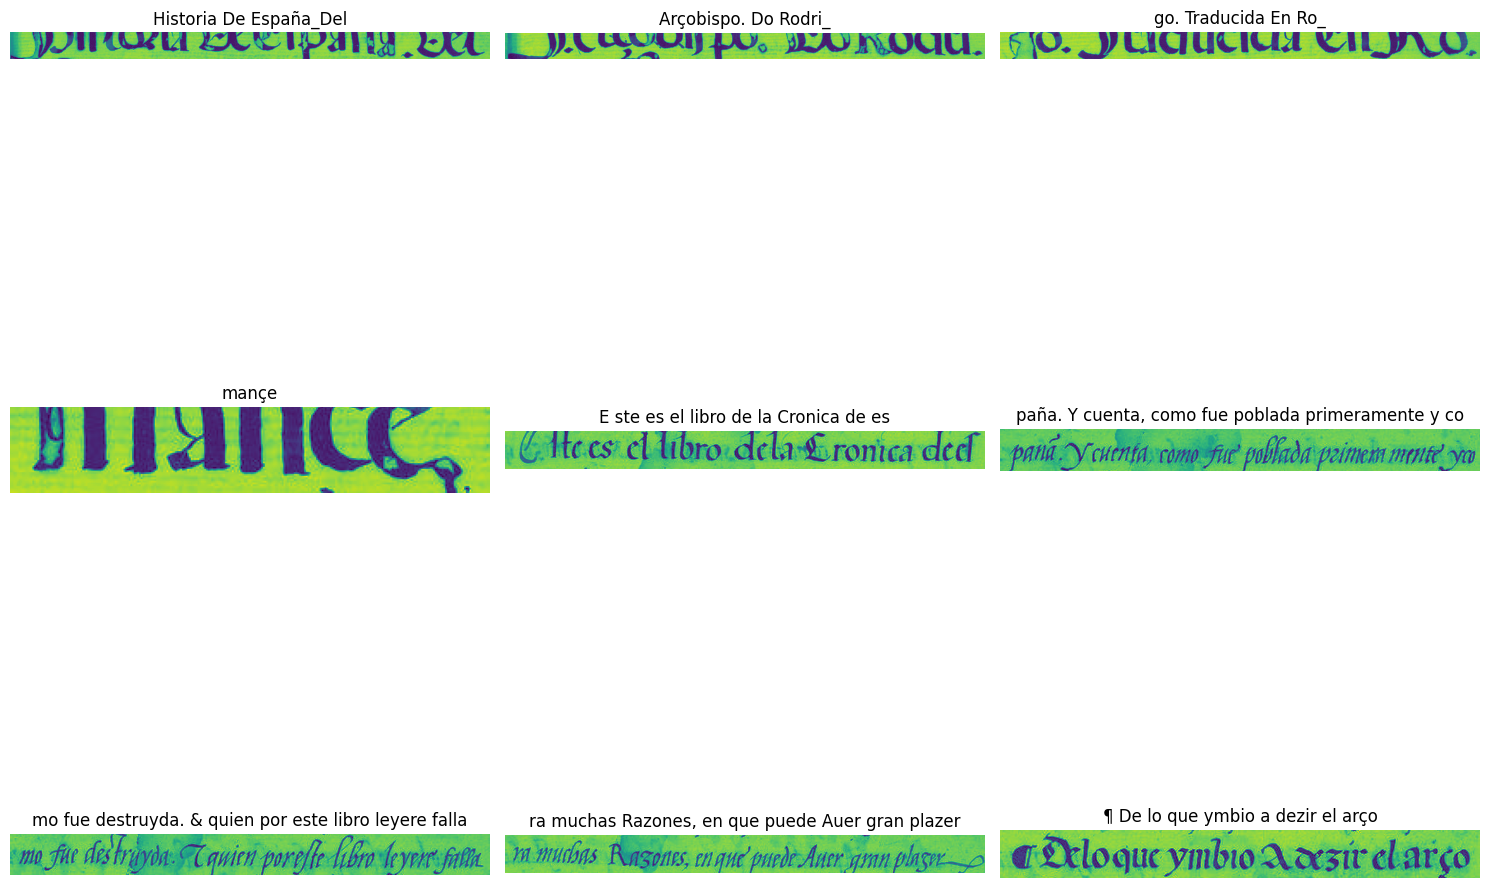

In [8]:
display_train_images(df_train, num=9, rand=False)

In [9]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df_train, test_size=0.2)
# we reset the indices to start from zero
train_df.reset_index(drop=True, inplace=True)
test_df.reset_index(drop=True, inplace=True)

In [10]:
import torch
from torch.utils.data import Dataset
from PIL import Image

class SpanishOldWritten(Dataset):
    def __init__(self, root_dir, df, processor, max_target_length=128):
        self.root_dir = root_dir
        self.df = df
        self.processor = processor
        self.max_target_length = max_target_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # get file name + text 
        file_name = self.df['unique Id'][idx]
        text = self.df['transcription'][idx]
        # prepare image (i.e. resize + normalize)
        image_path = os.path.join(self.root_dir, file_name + ".png")
        image = Image.open(image_path).convert("RGB")
        pixel_values = self.processor(image, return_tensors="pt").pixel_values
        # add labels (input_ids) by encoding the text
        labels = self.processor.tokenizer(text, 
                                          padding="max_length", 
                                          max_length=self.max_target_length).input_ids
        # important: make sure that PAD tokens are ignored by the loss function
        labels = [label if label != self.processor.tokenizer.pad_token_id else -100 for label in labels]

        encoding = {"pixel_values": pixel_values.squeeze(), "labels": torch.tensor(labels)}
        return encoding

In [11]:
!pip install transformers

In [12]:

from transformers import TrOCRProcessor

processor = TrOCRProcessor.from_pretrained("microsoft/trocr-base-handwritten")
train_dataset = SpanishOldWritten(root_dir='Public_data/train_images/',
                           df=train_df,
                           processor=processor)
eval_dataset = SpanishOldWritten(root_dir='Public_data/train_images/',
                           df=test_df,
                           processor=processor)

In [13]:
print("Number of training examples:", len(train_dataset))
print("Number of validation examples:", len(eval_dataset))

Number of training examples: 12008
Number of validation examples: 3002


In [14]:
encoding = train_dataset[0]
for k,v in encoding.items():
  print(k, v.shape)

pixel_values torch.Size([3, 384, 384])
labels torch.Size([128])


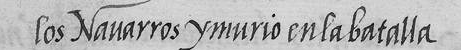

In [15]:
image = Image.open(train_dataset.root_dir + train_df['unique Id'][0] + ".png").convert("RGB")
image

In [16]:
labels = encoding['labels']
labels[labels == -100] = processor.tokenizer.pad_token_id
label_str = processor.decode(labels, skip_special_tokens=True)
print(label_str)

los Nauarros y murio en la batalla


In [17]:
from transformers import VisionEncoderDecoderModel

model = VisionEncoderDecoderModel.from_pretrained("microsoft/trocr-base-stage1")

VisionEncoderDecoderModel has generative capabilities, as `prepare_inputs_for_generation` is explicitly overwritten. However, it doesn't directly inherit from `GenerationMixin`. From 👉v4.50👈 onwards, `PreTrainedModel` will NOT inherit from `GenerationMixin`, and this model will lose the ability to call `generate` and other related functions.
  - If you're using `trust_remote_code=True`, you can get rid of this warning by loading the model with an auto class. See https://huggingface.co/docs/transformers/en/model_doc/auto#auto-classes
  - If you are the owner of the model architecture code, please modify your model class such that it inherits from `GenerationMixin` (after `PreTrainedModel`, otherwise you'll get an exception).
  - If you are not the owner of the model architecture class, please contact the model code owner to update it.


Some weights of VisionEncoderDecoderModel were not initialized from the model checkpoint at microsoft/trocr-base-stage1 and are newly initialized: ['encoder.pooler.dense.bias', 'encoder.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [18]:
# set special tokens used for creating the decoder_input_ids from the labels
model.config.decoder_start_token_id = processor.tokenizer.cls_token_id
model.config.pad_token_id = processor.tokenizer.pad_token_id
# make sure vocab size is set correctly
model.config.vocab_size = model.config.decoder.vocab_size

# set beam search parameters
model.config.eos_token_id = processor.tokenizer.sep_token_id
model.config.max_length = 80
model.config.early_stopping = True
model.config.no_repeat_ngram_size = 3
model.config.length_penalty = 2.0
model.config.num_beams = 4

In [19]:
!pip install accelerate

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [20]:
!pip install torch

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [21]:
from transformers import Seq2SeqTrainer, Seq2SeqTrainingArguments

num_training_steps = 1000  # This should be calculated based on your dataset size and batch size
half_steps = num_training_steps // 2

training_args = Seq2SeqTrainingArguments(
    predict_with_generate=True,
    evaluation_strategy="steps",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    fp16=True,
    output_dir="AI3",
    logging_steps=2,
    save_steps=half_steps,  # Save after 50% of the total steps
    save_total_limit=2,  # Optional: limit the number of saved models
    eval_steps=100,  # Evaluate every 200 steps
    num_train_epochs=1  # Run for only one epoch
)

/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/transformers/training_args.py:1545: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [22]:
!pip install evaluate jiwer

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [23]:
import numpy as np

def wer(reference, hypothesis):
    """
    Calculate the Word Error Rate (WER) between a reference and hypothesis sentence.
    WER is defined as the minimum number of word-level edits (insertions, deletions, substitutions)
    required to convert the hypothesis sentence into the reference sentence, divided by the total number of words in the reference.

    Parameters:
    reference (str): The ground truth sentence.
    hypothesis (str): The predicted sentence.

    Returns:
    float: The word error rate between the reference and hypothesis.
    """
    # Split the reference and hypothesis sentences into words
    reference_words = reference.split()
    hypothesis_words = hypothesis.split()

    # Create a matrix to store the distances
    d = np.zeros((len(reference_words) + 1, len(hypothesis_words) + 1), dtype=np.uint8)

    # Initialize the matrix
    for i in range(1, len(reference_words) + 1):
        d[i][0] = i
    for j in range(1, len(hypothesis_words) + 1):
        d[0][j] = j

    # Fill the matrix
    for i in range(1, len(reference_words) + 1):
        for j in range(1, len(hypothesis_words) + 1):
            if reference_words[i - 1] == hypothesis_words[j - 1]:
                d[i][j] = d[i - 1][j - 1]
            else:
                d[i][j] = min(d[i - 1][j], d[i][j - 1], d[i - 1][j - 1]) + 1

    # The WER is the number of errors divided by the total number of words in the reference sentence
    wer_value = d[len(reference_words)][len(hypothesis_words)] / len(reference_words)

    return wer_value

def compute_metrics(pred):
    labels_ids = pred.label_ids
    pred_ids = pred.predictions

    # Decode predictions and labels
    pred_str = processor.batch_decode(pred_ids, skip_special_tokens=True)
    labels_ids[labels_ids == -100] = processor.tokenizer.pad_token_id
    label_str = processor.batch_decode(labels_ids, skip_special_tokens=True)

    # Calculate WER for each sentence and take the mean
    wer_scores = [wer(ref, hyp) for ref, hyp in zip(label_str, pred_str)]
    avg_wer = np.mean(wer_scores)

    return {"wer": avg_wer}


In [24]:
from transformers import default_data_collator

# instantiate trainer
trainer = Seq2SeqTrainer(
    model=model,
    tokenizer=processor.feature_extractor,
    args=training_args,
    compute_metrics=compute_metrics,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    data_collator=default_data_collator,
)
trainer.train()

/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/transformers/models/trocr/processing_trocr.py:137: FutureWarning: `feature_extractor` is deprecated and will be removed in v5. Use `image_processor` instead.
  warnings.warn(


Step,Training Loss,Validation Loss,Wer
200,1.459200,1.571634,0.493297
400,0.945700,0.899310,0.318922
600,0.837100,0.750913,0.279805
800,0.690500,0.575828,0.222536
1000,0.476100,0.466540,0.190321
1200,0.359100,0.385296,0.154931
1400,0.398100,0.323738,0.141941


/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/transformers/generation/utils.py:1338: UserWarning: You have modified the pretrained model configuration to control generation. This is a deprecated strategy to control generation and will be removed in v5. Please use and modify the model generation configuration (see https://huggingface.co/docs/transformers/generation_strategies#default-text-generation-configuration )
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/transformers/modeling_utils.py:2618: UserWarning: Moving the following attributes in the config to the generation config: {'max_length': 80, 'early_stopping': True, 'num_beams': 4, 'length_penalty': 2.0, 'no_repeat_ngram_size': 3}. You are seeing this warning because you've set generation parameters in the model config, as opposed to in the generation config.
  warnings.warn(


TrainOutput(global_step=1501, training_loss=0.9943080580309976, metrics={'train_runtime': 5581.74, 'train_samples_per_second': 2.151, 'train_steps_per_second': 0.269, 'total_flos': 1.0625824571535655e+19, 'train_loss': 0.9943080580309976, 'epoch': 1.0})

In [25]:
model_train = VisionEncoderDecoderModel.from_pretrained("AI3/checkpoint-1501")

In [26]:
processor_train = TrOCRProcessor.from_pretrained("microsoft/trocr-base-handwritten")

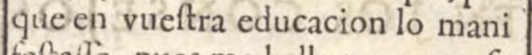

In [35]:
image = Image.open('Public_data/test_images/Page_1/L_3.png').convert("RGB")
image

In [36]:
pixel_values = processor(image, return_tensors="pt").pixel_values
print(pixel_values.shape)


torch.Size([1, 3, 384, 384])


In [37]:
generated_ids = model_train.generate(pixel_values)
generated_text = processor_train.batch_decode(generated_ids, skip_special_tokens=True)[0]
print(f"generated_text: {generated_text}")

generated_text: que en vuestra educacion lo mani


In [30]:
from tqdm import tqdm

In [31]:
test_df = pd.read_csv("Public_data/test.csv")
predictions = []

for _, row in tqdm(test_df.iterrows(), total=len(test_df)):
    unique_id = row['unique Id']

    parts = unique_id.split('_')
    page_number = parts[1]
    line_number = parts[3]

    image_path = f'Public_data/test_images/Page_{page_number}/L_{line_number}.png'

    image = Image.open(image_path).convert("RGB")

    pixel_values = processor_train(image, return_tensors="pt").pixel_values

    generated_ids = model_train.generate(pixel_values)
    generated_text = processor_train.batch_decode(generated_ids, skip_special_tokens=True)[0]

    predictions.append(generated_text)

test_df['prediction'] = predictions

test_df.to_csv("test_final.csv", index=False)

print("Predictions saved to test_final.csv")


  0%|          | 0/168 [00:00<?, ?it/s]

100%|██████████| 168/168 [10:49<00:00,  3.86s/it]

Predictions saved to test_final.csv
